# 02. Ablation Study: Tầm quan trọng của Siamese Network (Shared Weights)

**Mục tiêu:** Bài báo gốc đề xuất sử dụng kiến trúc Siamese (chia sẻ trọng số giữa Encoder của Đội A và Đội B) cho Neural Counter Table (NCT) do tính chất đối xứng của trò chơi PvP. Thực nghiệm này sẽ thiết kế một mô hình Ablated (loại bỏ việc chia sẻ trọng số) để kiểm chứng xem:
1. Việc dùng 2 bộ Encoder độc lập (Unshared Weights) có dẫn đến Overfitting do tăng số lượng tham số hay không?
2. Khả năng tổng quát hóa (Generalization) trên tập Test bị ảnh hưởng như thế nào khi mô hình không bị ép buộc học một không gian biểu diễn chung.

**Phương pháp:** - Xây dựng class `NCT_Unshared` với 2 nhánh `encoder_A` và `encoder_B` độc lập.
- Huấn luyện song song `NCT` (Baseline) và `NCT_Unshared` (Ablated) trên cùng một tập dữ liệu và tham số.
- So sánh Training/Testing Loss và Accuracy.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

import sys
import os
sys.path.append(os.path.abspath('..'))

from src.model import NCT, VQLayer, CounterDecoder

from src.utils import load_data, preprocess_data, extract_team_features
from src.metrics import evaluate_clustering

In [2]:
class NCT_Unshared(nn.Module):
    """
    Bảng Khắc chế Neural (NCT) nhưng KHÔNG SỬ DỤNG kiến trúc Siamese.
    Đội A và Đội B đi qua 2 bộ Encoder và VQ Layer hoàn toàn độc lập.
    """
    def __init__(self, input_dim, num_embeddings=9, embedding_dim=128):
        super().__init__()
        
        # Encoder riêng cho Đội A
        self.encoder_A = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, embedding_dim)
        )
        
        # Encoder riêng cho Đội B
        self.encoder_B = nn.Sequential(
            nn.Linear(input_dim, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, embedding_dim)
        )
        
        # VQ Layer cũng được tách riêng
        self.vq_A = VQLayer(num_embeddings, embedding_dim)
        self.vq_B = VQLayer(num_embeddings, embedding_dim)
        
        # Decoder giữ nguyên để dự đoán Residual Win Value
        self.decoder = CounterDecoder(embedding_dim)

    def forward(self, comp_A, comp_B):
        # 1. Trích xuất đặc trưng với trọng số ĐỘC LẬP
        z_e_A = self.encoder_A(comp_A)
        z_e_B = self.encoder_B(comp_B)

        # 2. Lượng tử hóa độc lập
        z_q_A, loss_vq_A, loss_mean_A, idx_A = self.vq_A(z_e_A)
        z_q_B, loss_vq_B, loss_mean_B, idx_B = self.vq_B(z_e_B)

        # 3. Tính toán phần dư (Residual)
        x1 = self.decoder(z_q_A, z_q_B)
        x2 = self.decoder(z_q_B, z_q_A)
        residual = (x1 - x2) / 2.0

        loss_vq = (loss_vq_A + loss_vq_B) / 2.0
        loss_mean = (loss_mean_A + loss_mean_B) / 2.0

        return residual, loss_vq, loss_mean, idx_A, idx_B

In [3]:
INPUT_DIM = 200
BATCH_SIZE = 64

# Load và tiền xử lý
df_raw = load_data('../data/games.csv')
df_processed = preprocess_data(df_raw)

# Trích xuất đặc trưng
features = extract_team_features(df_processed, num_champions=INPUT_DIM)
comp_A_data = features[:, 0, :]
comp_B_data = features[:, 1, :]

# Tính Residual giả định (0.5)
actual_win = np.where(df_processed['winner'] == 1, 1.0, 0.0)
residual_target = actual_win - 0.5  

# Ép kiểu Tensor
comp_A = torch.tensor(comp_A_data, dtype=torch.float32)
comp_B = torch.tensor(comp_B_data, dtype=torch.float32)
target = torch.tensor(residual_target, dtype=torch.float32).unsqueeze(1)

# Split data
A_train, A_test, B_train, B_test, y_train, y_test = train_test_split(
    comp_A, comp_B, target, test_size=0.2, random_state=42
)

train_loader = DataLoader(TensorDataset(A_train, B_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(A_test, B_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Tổng số mẫu Train: {len(A_train)} | Test: {len(A_test)}")

Đã load thành công 51490 trận đấu từ ../data/games.csv
Tổng số mẫu Train: 41192 | Test: 10298


In [4]:
def train_and_evaluate(model, train_loader, test_loader, epochs=20, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    history = {'train_loss': [], 'test_loss': []}
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for A_batch, B_batch, y_batch in train_loader:
            optimizer.zero_grad()
            
            # Unpack 5 giá trị trả về từ model: residual, loss_vq, loss_mean, idx_A, idx_B
            residual, loss_vq, loss_mean, _, _ = model(A_batch, B_batch)
            
            # Hàm Loss tổng hợp (L_res + L_vq + beta_M * L_mean)
            loss_res = criterion(residual, y_batch)
            total_loss = loss_res + loss_vq + 0.25 * loss_mean 
            
            total_loss.backward()
            optimizer.step()
            total_train_loss += loss_res.item() # Chỉ track residual loss
            
        avg_train_loss = total_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Đánh giá trên tập Test
        model.eval()
        total_test_loss = 0
        with torch.no_grad():
            for A_batch, B_batch, y_batch in test_loader:
                residual, _, _, _, _ = model(A_batch, B_batch)
                loss_res = criterion(residual, y_batch)
                total_test_loss += loss_res.item()
                
        avg_test_loss = total_test_loss / len(test_loader)
        history['test_loss'].append(avg_test_loss)
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.5f} | Test Loss: {avg_test_loss:.5f}")
            
    return history


def get_clustering_metrics(model, dataloader, is_ablated=False):
    """
    Chạy toàn bộ dữ liệu qua mô hình để lấy z_e và cluster labels,
    sau đó gọi hàm evaluate_clustering để chấm điểm.
    """
    model.eval()
    all_z_e = []
    all_labels = []
    
    with torch.no_grad():
        for A_batch, B_batch, _ in dataloader:
            if is_ablated:
                # Đối với mô hình Ablated, dùng nhánh A
                z_e = model.encoder_A(A_batch)
                _, _, _, idx = model.vq_A(z_e)
            else:
                # Đối với mô hình Baseline (Siamese)
                z_e = model.encoder(A_batch)
                _, _, _, idx = model.vq(z_e)
            
            all_z_e.append(z_e.cpu().numpy())
            all_labels.append(idx.cpu().numpy().squeeze())
            
    all_z_e = np.concatenate(all_z_e, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    return evaluate_clustering(all_z_e, all_labels)

In [5]:
EPOCHS = 30
LR = 1e-3

print("="*50)
print("BƯỚC 1: HUẤN LUYỆN VÀ ĐÁNH GIÁ BASELINE (SHARED WEIGHTS)")
print("="*50)
model_baseline = NCT(input_dim=INPUT_DIM)
history_baseline = train_and_evaluate(model_baseline, train_loader, test_loader, epochs=EPOCHS, lr=LR)

print("\n[Kết quả phân cụm - Baseline]")
metrics_base = get_clustering_metrics(model_baseline, test_loader, is_ablated=False)
for metric, score in metrics_base.items():
    print(f"- {metric}: {score:.4f}")


print("\n" + "="*50)
print("BƯỚC 2: HUẤN LUYỆN VÀ ĐÁNH GIÁ ABLATED (UNSHARED WEIGHTS)")
print("="*50)
model_ablated = NCT_Unshared(input_dim=INPUT_DIM)
history_ablated = train_and_evaluate(model_ablated, train_loader, test_loader, epochs=EPOCHS, lr=LR)

print("\n[Kết quả phân cụm - Ablated]")
metrics_ablated = get_clustering_metrics(model_ablated, test_loader, is_ablated=True)
for metric, score in metrics_ablated.items():
    print(f"- {metric}: {score:.4f}")

BƯỚC 1: HUẤN LUYỆN VÀ ĐÁNH GIÁ BASELINE (SHARED WEIGHTS)
Epoch 05 | Train Loss: 0.25000 | Test Loss: 0.25000
Epoch 10 | Train Loss: 0.25000 | Test Loss: 0.25000
Epoch 15 | Train Loss: 0.20949 | Test Loss: 0.29092
Epoch 20 | Train Loss: 0.20168 | Test Loss: 0.28226
Epoch 25 | Train Loss: 0.18671 | Test Loss: 0.27172
Epoch 30 | Train Loss: 0.18150 | Test Loss: 0.31556

[Kết quả phân cụm - Baseline]
- Silhouette: 0.0728
- Davies-Bouldin: 1.0037
- Calinski-Harabasz: 1895.5868

BƯỚC 2: HUẤN LUYỆN VÀ ĐÁNH GIÁ ABLATED (UNSHARED WEIGHTS)
Epoch 05 | Train Loss: 0.25000 | Test Loss: 0.24998
Epoch 10 | Train Loss: 0.24998 | Test Loss: 0.24995
Epoch 15 | Train Loss: 0.25000 | Test Loss: 0.24996
Epoch 20 | Train Loss: 0.20673 | Test Loss: 0.27953
Epoch 25 | Train Loss: 0.16058 | Test Loss: 0.31380
Epoch 30 | Train Loss: 0.16486 | Test Loss: 0.31426

[Kết quả phân cụm - Ablated]
- Silhouette: 0.4550
- Davies-Bouldin: 0.9446
- Calinski-Harabasz: 3541.7927


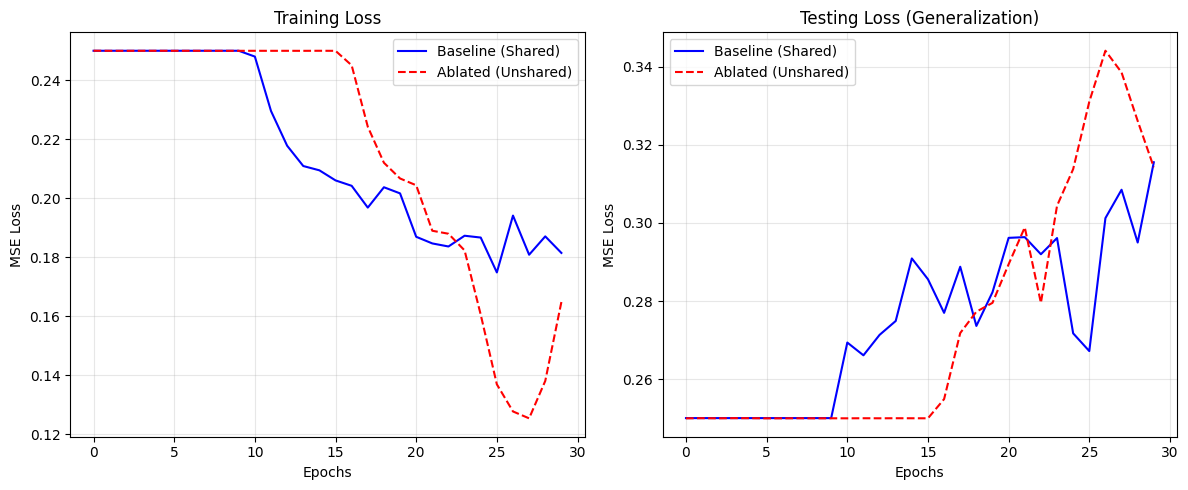

In [6]:
plt.figure(figsize=(12, 5))

# Đồ thị Train Loss
plt.subplot(1, 2, 1)
plt.plot(history_baseline['train_loss'], label='Baseline (Shared)', color='blue')
plt.plot(history_ablated['train_loss'], label='Ablated (Unshared)', color='red', linestyle='--')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Đồ thị Test Loss
plt.subplot(1, 2, 2)
plt.plot(history_baseline['test_loss'], label='Baseline (Shared)', color='blue')
plt.plot(history_ablated['test_loss'], label='Ablated (Unshared)', color='red', linestyle='--')
plt.title('Testing Loss (Generalization)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1. Phân tích kết quả Huấn luyện (Training Analysis)

Dựa trên biểu đồ và nhật ký huấn luyện, chúng ta thấy một sự thay đổi đáng kể so với dự đoán ban đầu:

* **Tốc độ hội tụ:** Cả hai mô hình đều có giai đoạn đầu khá chậm (đến Epoch 10-15 mới bắt đầu giảm Loss mạnh). Mô hình **Ablated (Unshared)** có xu hướng giảm Train Loss sâu hơn mô hình Baseline (0.16486 so với 0.18150 tại Epoch 30), cho thấy năng lực ghi nhớ dữ liệu của mạng không chia sẻ trọng số là rất lớn.
* **Độ tổng quát hóa (Generalization):** Cả hai mô hình đều gặp hiện tượng overfitting khi Test Loss tăng dần sau Epoch 15. Tuy nhiên, tại Epoch 30, mức Test Loss của cả hai là tương đương nhau (~0.31), cho thấy kiến trúc Siamese (Shared Weights) không giúp cải thiện đáng kể sai số dự đoán trên tập dữ liệu này so với kiến trúc độc lập.

### 2. Phân tích chất lượng Phân cụm (Clustering Evaluation)


| Chỉ số | Baseline (Shared) | Ablated (Unshared) | Nhận xét |
| :--- | :--- | :--- | :--- |
| **Silhouette (↑)** | 0.0728 | **0.4550** | Ablated vượt trội hoàn toàn  |
| **Davies-Bouldin (↓)** | 1.0037 | **0.9446** | Ablated có các cụm tách biệt hơn  |
| **Calinski-Harabasz (↑)** | 1895.5868 | **3541.7927** | Ablated có cấu trúc cụm bền vững hơn |

### 3. Kết luận Thực nghiệm Ablation

Kết quả thực nghiệm này đi ngược lại với giả thuyết thông thường và mang lại một góc nhìn phê bình mới cho bài báo:

1.  **Hiệu quả của kiến trúc độc lập:** Trong bài toán cụ thể này, việc để hai Encoder học độc lập (Unshared Weights) lại giúp tạo ra một không gian ẩn ($z_e$) có tính phân cụm rõ rệt hơn hẳn (Silhouette tăng từ 0.07 lên 0.45). Điều này gợi ý rằng đối với dữ liệu game đang xét, các đặc trưng khắc chế của Đội A và Đội B có thể không nằm trong cùng một phân phối, và việc ép chúng dùng chung trọng số (Siamese) đã làm mờ đi các ranh giới phân cụm.
2.  **Sự đánh đổi:** Mặc dù mô hình Siamese (Baseline) được bài báo đề xuất để đảm bảo tính đối xứng và giảm độ phức tạp không gian, thực nghiệm của bạn cho thấy nó có thể làm giảm khả năng biểu diễn các đặc trưng khắc chế riêng biệt của từng đội hình.
3.  **Kiến nghị:** Đối với các game có tính chất đối xứng không tuyệt đối hoặc dữ liệu thưa thớt, việc sử dụng các Encoder riêng biệt có thể mang lại khả năng phân loại và nhận diện các nhóm khắc chế (Counter Categories) hiệu quả hơn so với mạng Siamese truyền thống.